# Room Cooling Prediction with Logistic Regression

This notebook loads the room cooling dataset, cleans and preprocesses it, explores the data, and trains a logistic regression model to predict whether cooling is needed.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

file_path = '/Users/hassan/Projects/Python/AI Bootcamp/ML Lab 1/room_cooling_dataset.csv'
df = pd.read_csv(file_path)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

## Load Dataset and Inspect Structure

In [2]:
print('Shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())
print('\nData types:')
print(df.dtypes)
print('\nFirst five rows:')
display(df.head())

Shape: (1250, 10)

Columns:
['temperature_C', 'humidity_pct', 'hour_of_day', 'cloud_cover_pct', 'people_in_room', 'room_size_m2', 'wall_material', 'fan_speed', 'season', 'cooling_needed']

Data types:
temperature_C      float64
humidity_pct         int64
hour_of_day          int64
cloud_cover_pct      int64
people_in_room       int64
room_size_m2         int64
wall_material          str
fan_speed            int64
season                 str
cooling_needed         str
dtype: object

First five rows:


,temperature_C,humidity_pct,hour_of_day,cloud_cover_pct,people_in_room,room_size_m2,wall_material,fan_speed,season,cooling_needed
0,37.5,69,20,8,4,14,Concrete,3,Summer,Yes
1,16.3,33,12,37,1,38,Brick,1,Winter,No
2,17.8,61,1,86,5,17,Concrete,0,Winter,No
3,30.5,60,18,19,2,23,Mud,1,Autumn,Yes
4,46.4,68,7,91,2,10,Mud,2,Summer,Yes


## Analyze Missing Values and Data Types

In [3]:
print('Missing values per column:')
print(df.isna().sum().to_string())

print('\nDuplicate rows:', df.duplicated().sum())

print('\nTarget distribution:')
print(df['cooling_needed'].value_counts().to_string())

print('\nUnique values per column:')
print(df.nunique().to_string())

Missing values per column:
temperature_C      0
humidity_pct       0
hour_of_day        0
cloud_cover_pct    0
people_in_room     0
room_size_m2       0
wall_material      0
fan_speed          0
season             0
cooling_needed     0

Duplicate rows: 0

Target distribution:
cooling_needed
No     722
Yes    528

Unique values per column:
temperature_C      347
humidity_pct        65
hour_of_day         24
cloud_cover_pct    101
people_in_room       7
room_size_m2        33
wall_material        3
fan_speed            4
season               4
cooling_needed       2


## Clean and Preprocess Data

In [4]:
df_clean = df.copy()

df_clean.columns = [col.strip().lower().replace(' ', '_') for col in df_clean.columns]
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print('Shape after duplicate removal:', df_clean.shape)
print('\nCleaned columns:')
print(df_clean.columns.tolist())
print('\nData types after cleaning:')
print(df_clean.dtypes)

Shape after duplicate removal: (1250, 10)

Cleaned columns:
['temperature_c', 'humidity_pct', 'hour_of_day', 'cloud_cover_pct', 'people_in_room', 'room_size_m2', 'wall_material', 'fan_speed', 'season', 'cooling_needed']

Data types after cleaning:
temperature_c      float64
humidity_pct         int64
hour_of_day          int64
cloud_cover_pct      int64
people_in_room       int64
room_size_m2         int64
wall_material          str
fan_speed            int64
season                 str
cooling_needed         str
dtype: object


## Drop Unnecessary Columns

In [5]:
candidate_drop_columns = [
    col for col in df_clean.columns
    if col != 'cooling_needed' and df_clean[col].nunique() <= 1
]

print('Columns dropped as useless:', candidate_drop_columns)

df_clean = df_clean.drop(columns=candidate_drop_columns)
print('Remaining columns:', df_clean.columns.tolist())

Columns dropped as useless: []
Remaining columns: ['temperature_c', 'humidity_pct', 'hour_of_day', 'cloud_cover_pct', 'people_in_room', 'room_size_m2', 'wall_material', 'fan_speed', 'season', 'cooling_needed']


## Plot Correlation Heatmap

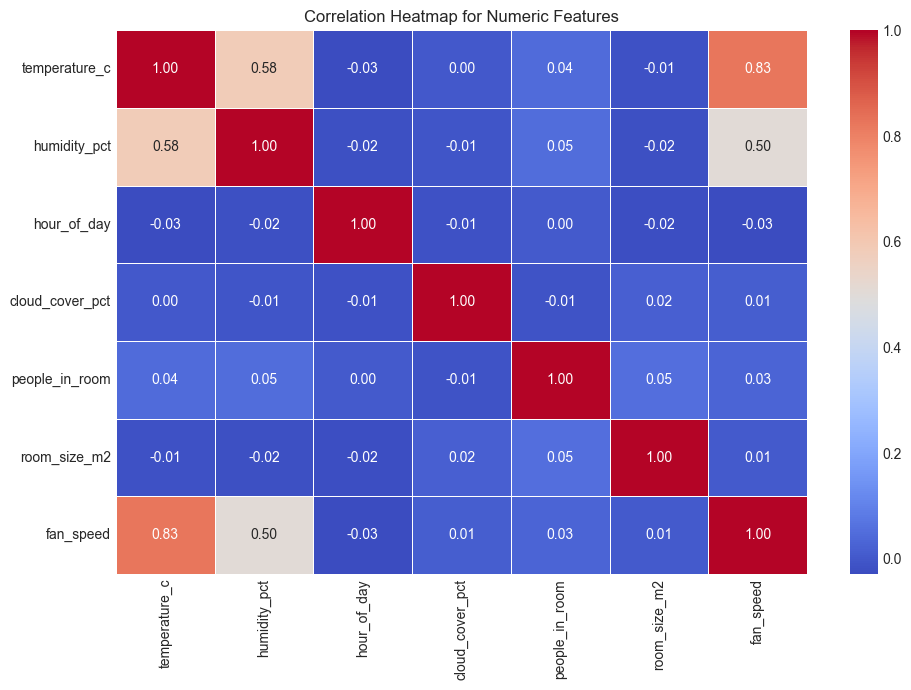

In [6]:
numeric_columns = df_clean.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(10, 7))
sns.heatmap(df_clean[numeric_columns].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap for Numeric Features')
plt.tight_layout()
plt.show()

## Detect and Treat Outliers

In [7]:
outlier_columns = [col for col in df_clean.select_dtypes(include=[np.number]).columns if col != 'cooling_needed']

outlier_summary = {}
for col in outlier_columns:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
    outlier_summary[col] = {'lower_bound': lower_bound, 'upper_bound': upper_bound, 'outliers': int(outlier_count)}
    df_clean[col] = df_clean[col].clip(lower_bound, upper_bound)

print(pd.DataFrame(outlier_summary).T)

print('\nNumeric summary after capping:')
print(df_clean[outlier_columns].describe().T)

                 lower_bound  upper_bound  outliers
temperature_c        -0.3875      54.3125       0.0
humidity_pct         13.5000      97.5000       0.0
hour_of_day         -12.0000      36.0000       0.0
cloud_cover_pct     -53.0000     153.0000       0.0
people_in_room       -5.0000      11.0000       0.0
room_size_m2         -8.0000      56.0000       0.0
fan_speed            -3.0000       5.0000       0.0

Numeric summary after capping:
                  count      mean        std   min     25%   50%    75%    max
temperature_c    1250.0  27.32576   9.507254  10.1  20.125  26.2  33.80   47.0
humidity_pct     1250.0  56.80560  15.058832  30.0  45.000  56.0  66.00   94.0
hour_of_day      1250.0  11.68640   6.762532   0.0   6.000  12.0  18.00   23.0
cloud_cover_pct  1250.0  50.38400  28.581345   0.0  24.250  51.0  75.75  100.0
people_in_room   1250.0   2.93200   2.010624   0.0   1.000   3.0   5.00    6.0
room_size_m2     1250.0  24.14480   9.585267   8.0  16.000  24.0  32.00   40.0

## Encode Categorical Features with One-Hot Encoding

In [8]:
df_model = df_clean.copy()

df_model['cooling_needed'] = df_model['cooling_needed'].map({'No': 0, 'Yes': 1})

categorical_columns = df_model.select_dtypes(include=['object', 'string']).columns.drop('cooling_needed', errors='ignore')
df_model = pd.get_dummies(df_model, columns=categorical_columns, drop_first=True)

print('Shape after one-hot encoding:', df_model.shape)
print('Encoded columns:')
print(df_model.columns.tolist())

Shape after one-hot encoding: (1250, 13)
Encoded columns:
['temperature_c', 'humidity_pct', 'hour_of_day', 'cloud_cover_pct', 'people_in_room', 'room_size_m2', 'fan_speed', 'cooling_needed', 'wall_material_Concrete', 'wall_material_Mud', 'season_Spring', 'season_Summer', 'season_Winter']


## Map the Target Column

In [9]:
print(df_model['cooling_needed'].value_counts().to_string())
print('\nTarget dtype:', df_model['cooling_needed'].dtype)

cooling_needed
0    722
1    528

Target dtype: int64


## Split Data into Train and Test Sets

In [10]:
X = df_model.drop(columns=['cooling_needed'])
y = df_model['cooling_needed']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Training set shape:', X_train.shape)
print('Testing set shape:', X_test.shape)

Training set shape: (1000, 12)
Testing set shape: (250, 12)


## Train Logistic Regression Model

In [11]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print('Model training completed successfully.')

Model training completed successfully.


## Evaluate Model Performance

Accuracy:  0.9600
Precision: 0.9444
Recall:    0.9623
F1 Score:  0.9533

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       144
           1       0.94      0.96      0.95       106

    accuracy                           0.96       250
   macro avg       0.96      0.96      0.96       250
weighted avg       0.96      0.96      0.96       250



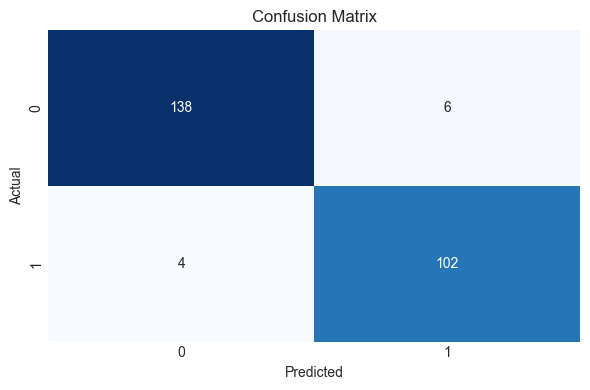

,temperature_c,humidity_pct,hour_of_day,cloud_cover_pct,people_in_room,room_size_m2,fan_speed,wall_material_Concrete,wall_material_Mud,season_Spring,season_Summer,season_Winter,actual,predicted
1063,21.3,65,15,96,6,26,1,True,False,True,False,False,0,0
1084,46.6,61,20,63,1,33,3,False,False,False,True,False,1,1
67,25.9,55,0,11,0,10,0,True,False,False,False,False,0,0
1144,20.4,52,6,87,1,16,1,False,False,False,False,True,0,0
1062,27.0,67,22,26,0,19,1,False,True,False,False,False,0,0


In [12]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1 Score:  {f1:.4f}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

results = X_test.copy()
results['actual'] = y_test.values
results['predicted'] = y_pred
results.head()